# Quantum-preconditioned vs baseline (Gurobi)

This notebook reads the CSV produced by `scripts/run_experiment.py` and plots baseline objective vs the baseline-evaluated objective of solutions found by the preconditioned models.

In [6]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# If you want to run the solver *from this notebook* and see Gurobi logs in the output,
# make sure this notebook kernel is the conda env that has `gurobipy` (e.g. `benchmark`).

# Allow importing the local package without installing it.
REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Toggle this to re-run optimization from the notebook.
RUN_SOLVES = True

results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)

if RUN_SOLVES:
    from qp_gurobi.solve import solve_from_paths
    import re
    
    n, seed, layers = 28, 0, 1
    instance_dir = Path('../Data') / f'N={n}' / f'seed={seed}'
    baseline_path = instance_dir / 'problem.dat'
    layer_dir = instance_dir / f'n_qaoa_layers={layers}'
    
    pen_re = re.compile(r"preconditioned_problem_pen=(?P<pen>[0-9]+\.[0-9]+)\.dat$")
    precond = []
    for p in sorted(layer_dir.glob('preconditioned_problem_pen=*.dat')):
        m = pen_re.search(p.name)
        if m:
            precond.append((float(m.group('pen')), p))
    
    out_csv = results_dir / f'N={n}_seed={seed}_layers={layers}.csv'
    log_dir = results_dir / f'logs_N={n}_seed={seed}_layers={layers}'
    
    # output_flag=1 streams the full Gurobi log into the cell output.
    res = solve_from_paths(
        baseline_path=baseline_path,
        preconditioned_paths=precond,
        output_flag=1,
        log_dir=log_dir,
    )
    
    df = pd.DataFrame([r.to_row() for r in res])
    df.to_csv(out_csv, index=False)
    print(f'Wrote results to {out_csv}')
    print(f'Wrote per-run logs to {log_dir}')
else:
    # Auto-pick the newest results CSV.
    csv_candidates = sorted(results_dir.glob('*.csv'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not csv_candidates:
        raise FileNotFoundError(f'No CSV files found under {results_dir.resolve()}')
    csv_path = csv_candidates[0]
    print(f'Using results file: {csv_path}')
    
    # Force bitstrings to load as strings so leading zeros are preserved.
    df = pd.read_csv(
        csv_path,
        dtype={
            'name': 'string',
            'x_bits': 'string',
            'z_bits': 'string',
        },
    )
    # If pandas previously parsed and dropped leading zeros, restore fixed width using N.
    if 'n' in df.columns:
        n_max = int(df['n'].max())
        df['x_bits'] = df['x_bits'].str.zfill(n_max)
        df['z_bits'] = df['z_bits'].str.zfill(n_max)

df

Set parameter LogFile to value "../results/logs_N=28_seed=0_layers=1/baseline.log"
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 13th Gen Intel(R) Core(TM) i7-1365U, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1 rows, 28 columns and 28 nonzeros
Model fingerprint: 0x804eecaa
Model has 378 quadratic objective terms
Variable types: 0 continuous, 28 integer (28 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+01, 4e+01]
  QObjective range [2e-03, 8e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+01, 1e+01]
Found heuristic solution: objective 216.8666954
Presolve time: 0.05s
Presolved: 379 rows, 406 columns, 1162 nonzeros
Variable types: 0 continuous, 406 integer (406 binary)

Root relaxation: objective -2.041700e-13, 26 iterations, 0.01 seconds (0.00 work units)

    Nodes    |    Current Node    |    

,name,n,objective_model,objective_baseline,penalty,mip_status,runtime_sec,mip_gap,x_bits,z_bits,sum_z
0,baseline,28,176.912749,176.912749,NaN,2,16.238960,0.0,1110001111000001101010011001,+++---++++-----++-+-+--++--+,0
1,precond_pen=0.200,28,-14.285708,176.912749,0.2,2,0.890784,0.0,1110001111000001101010011001,+++---++++-----++-+-+--++--+,0
2,precond_pen=0.300,28,-17.083644,177.542810,0.3,2,0.511365,0.0,0101110000011110010101100110,-+-+++-----++++--+-+-++--++-,0
3,precond_pen=0.400,28,-10.328083,177.075753,0.4,2,0.502302,0.0,0101110000011100010111100110,-+-+++-----+++---+-++++--++-,0


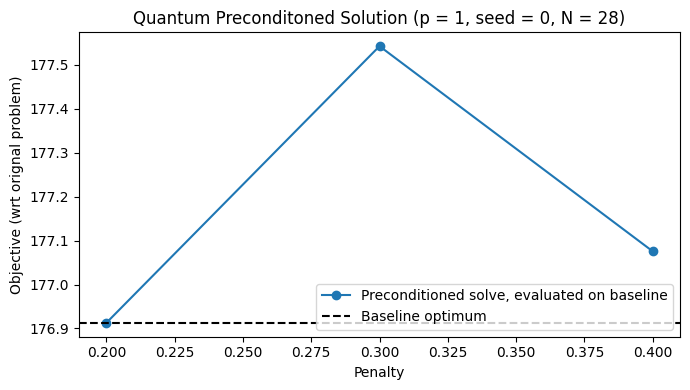

In [4]:
baseline = df[df['name'] == 'baseline'].iloc[0]
baseline_obj = baseline['objective_baseline']

pre = df[df['penalty'].notna()].copy()
pre = pre.sort_values('penalty')

plt.figure(figsize=(7,4))
plt.plot(pre['penalty'], pre['objective_baseline'], marker='o', label='Preconditioned solve, evaluated on baseline')
plt.axhline(baseline_obj, color='k', linestyle='--', label='Baseline optimum')
plt.xlabel('Penalty')
plt.ylabel('Objective (wrt orignal problem)')
plt.title('Quantum Preconditoned Solution (p = 1, seed = 0, N = 28)')
plt.legend()
plt.tight_layout()
plt.show()

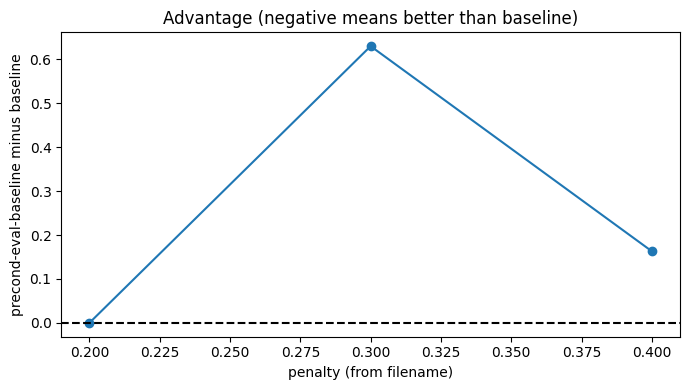

In [3]:
pre['gap_to_baseline'] = pre['objective_baseline'] - baseline_obj

plt.figure(figsize=(7,4))
plt.plot(pre['penalty'], pre['gap_to_baseline'], marker='o')
plt.axhline(0.0, color='k', linestyle='--')
plt.xlabel('penalty (from filename)')
plt.ylabel('precond-eval-baseline minus baseline')
plt.title('Advantage (negative means better than baseline)')
plt.tight_layout()
plt.show()

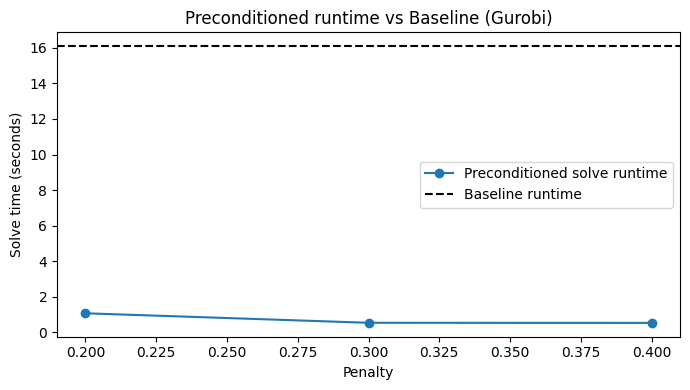

,penalty,runtime_sec,speedup_vs_baseline
1,0.2,1.070494,15.036581
2,0.3,0.535286,30.070972
3,0.4,0.529991,30.371405


In [5]:
# Timing comparison: penalty sweeps vs baseline
baseline_runtime = float(baseline['runtime_sec'])
pre_runtime = pre[['penalty', 'runtime_sec']].copy()

plt.figure(figsize=(7,4))
plt.plot(pre_runtime['penalty'], pre_runtime['runtime_sec'], marker='o', label='Preconditioned solve runtime')
plt.axhline(baseline_runtime, color='k', linestyle='--', label=f'Baseline runtime')
plt.xlabel('Penalty')
plt.ylabel('Solve time (seconds)')
plt.title('Preconditioned runtime vs Baseline (Gurobi)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional: speedup relative to baseline (>1 means faster than baseline)
pre_runtime['speedup_vs_baseline'] = baseline_runtime / pre_runtime['runtime_sec']
pre_runtime